# Step 6: Gradient Boosting Models

## 🎯 Objective:
Mengganti model dengan **Gradient Boosting** yang lebih powerful:
- **XGBoost** (eXtreme Gradient Boosting)
- **LightGBM** (Light Gradient Boosting Machine)
- **CatBoost** (Categorical Boosting)

## 💡 Why Gradient Boosting?

### **Random Forest vs Gradient Boosting:**
```
Random Forest:
- Bagging (parallel trees)
- Each tree independent
- Average predictions
- Good, but not optimal

Gradient Boosting:
- Boosting (sequential trees)
- Each tree learns from previous errors
- Weighted sum of predictions
- BETTER for structured data (like financial features)
```

### **Why These 3 Models?**
```
XGBoost:
✅ Industry standard
✅ Regularization (L1, L2)
✅ Handles missing values
✅ Proven in Kaggle competitions

LightGBM:
✅ FASTER than XGBoost
✅ Better accuracy on some datasets
✅ Leaf-wise tree growth
✅ Lower memory usage

CatBoost:
✅ Handles categorical features well
✅ Robust to overfitting
✅ Ordered boosting
✅ Good default parameters
```

## 📊 Configuration:
- **Features**: Same 10 features from Step 4
- **Target**: Same binary classification (next-day > 0)
- **Train/Test**: Same split (2023-2024 / 2025)
- **NEW**: Compare 5 models (RF, LR, XGB, LGBM, CatBoost)

In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
)

# Gradient Boosting Models
import xgboost as xgb
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings('ignore')

# Config
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries loaded successfully!")
print("\n📦 Step 6: Gradient Boosting Models")
print("  Models: XGBoost, LightGBM, CatBoost")
print("  Comparison: RF vs LR vs XGB vs LGBM vs CatBoost")

✅ Libraries loaded successfully!

📦 Step 6: Gradient Boosting Models
  Models: XGBoost, LightGBM, CatBoost
  Comparison: RF vs LR vs XGB vs LGBM vs CatBoost


## 1. Data Loading

In [5]:
# Load data
file_path = 'dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)

print(f"📊 Dataset loaded: {len(data)} rows")
print(f"📅 Date range: {data.index[0].date()} to {data.index[-1].date()}")
print(f"💰 Assets ({len(data.columns)}): {list(data.columns)}")

📊 Dataset loaded: 990 rows
📅 Date range: 2023-04-17 to 2025-12-31
💰 Assets (24): ['AAVE-USD', 'ADA-USD', 'BCH-USD', 'BNB-USD', 'BTC-USD', 'CRO-USD', 'DAI-USD', 'DASH-USD', 'DOGE-USD', 'ETH-USD', 'KCS-USD', 'LINK-USD', 'LTC-USD', 'MKR-USD', 'OKB-USD', 'PEPE24478-USD', 'SHIB-USD', 'SOL-USD', 'UNI7083-USD', 'USDC-USD', 'USDT-USD', 'XMR-USD', 'XRP-USD', 'ZEC-USD']


## 2. Feature Engineering (Same as Step 4)

In [6]:
# Calculate returns
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

# Create all 10 features (same as Step 4)
features = pd.DataFrame(index=returns.index)

# Step 1: Baseline
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

# Step 2: Multi-Timeframe
features['Vol_5'] = market_return.rolling(window=5).std()
features['Mom_5'] = market_return.rolling(window=5).mean()
features['Mom_10'] = market_return.rolling(window=10).mean()

# Step 3: Statistical
features['Skew_20'] = market_return.rolling(window=20).skew()
features['Kurt_20'] = market_return.rolling(window=20).kurt()

# Step 4: Cross-Asset
def rolling_avg_correlation(returns, window=20):
    corr_values = []
    for i in range(len(returns)):
        if i < window:
            corr_values.append(np.nan)
        else:
            window_data = returns.iloc[i-window:i]
            corr_matrix = window_data.corr()
            n = len(corr_matrix)
            avg_corr = (corr_matrix.sum().sum() - n) / (n * n - n)
            corr_values.append(avg_corr)
    return pd.Series(corr_values, index=returns.index)

print("🔄 Calculating cross-asset features...")
features['Avg_Correlation'] = rolling_avg_correlation(returns, window=20)
features['Return_Dispersion'] = returns.std(axis=1)

# Target (same as before)
features['Target'] = (market_return.shift(-1) > 0).astype(int)
features = features.dropna()

print("✅ All 10 features created")
print(f"\n📊 Target Distribution:")
target_dist = features['Target'].value_counts()
print(f"  Bearish (0): {target_dist[0]} ({target_dist[0]/len(features)*100:.1f}%)")
print(f"  Bullish (1): {target_dist[1]} ({target_dist[1]/len(features)*100:.1f}%)")

🔄 Calculating cross-asset features...
✅ All 10 features created

📊 Target Distribution:
  Bearish (0): 419 (45.2%)
  Bullish (1): 508 (54.8%)


## 3. Train/Test Split

In [7]:
# Feature columns (10 features)
feature_cols = [
    'Vol_20', 'Mom_20', 'Mom_50',
    'Vol_5', 'Mom_5', 'Mom_10',
    'Skew_20', 'Kurt_20',
    'Avg_Correlation', 'Return_Dispersion'
]

# Split by year
train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train = features.loc[train_mask, feature_cols]
y_train = features.loc[train_mask, 'Target']
X_test = features.loc[test_mask, feature_cols]
y_test = features.loc[test_mask, 'Target']

print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)
print(f"\n📚 Training Set: {len(X_train)} samples")
print(f"   Period: {X_train.index[0].date()} to {X_train.index[-1].date()}")
print(f"   Bearish: {(y_train==0).sum()} | Bullish: {(y_train==1).sum()}")

print(f"\n🧪 Testing Set: {len(X_test)} samples")
print(f"   Period: {X_test.index[0].date()} to {X_test.index[-1].date()}")
print(f"   Bearish: {(y_test==0).sum()} | Bullish: {(y_test==1).sum()}")
print("=" * 60)

TRAIN/TEST SPLIT

📚 Training Set: 562 samples
   Period: 2023-06-19 to 2024-12-31
   Bearish: 250 | Bullish: 312

🧪 Testing Set: 365 samples
   Period: 2025-01-01 to 2025-12-31
   Bearish: 169 | Bullish: 196


## 4. Model Training: All 5 Models

In [8]:
print("🔄 Training all 5 models...\n")

# 1. Random Forest (baseline from Step 4)
print("1️⃣ Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    min_samples_split=10,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
print(f"   ✅ RF Accuracy: {accuracy_score(y_test, rf_pred):.2%}")

# 2. Logistic Regression (baseline from Step 4)
print("\n2️⃣ Training Logistic Regression...")
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='lbfgs'
)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_proba = lr_model.predict_proba(X_test)[:, 1]
print(f"   ✅ LR Accuracy: {accuracy_score(y_test, lr_pred):.2%}")

# 3. XGBoost (NEW!)
print("\n3️⃣ Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train, verbose=False)
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
print(f"   ✅ XGB Accuracy: {accuracy_score(y_test, xgb_pred):.2%}")

# 4. LightGBM (NEW!)
print("\n4️⃣ Training LightGBM...")
lgbm_model = LGBMClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)
lgbm_model.fit(X_train, y_train)
lgbm_pred = lgbm_model.predict(X_test)
lgbm_proba = lgbm_model.predict_proba(X_test)[:, 1]
print(f"   ✅ LGBM Accuracy: {accuracy_score(y_test, lgbm_pred):.2%}")

# 5. CatBoost (NEW!)
print("\n5️⃣ Training CatBoost...")
catboost_model = CatBoostClassifier(
    iterations=200,
    depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=False
)
catboost_model.fit(X_train, y_train)
catboost_pred = catboost_model.predict(X_test)
catboost_proba = catboost_model.predict_proba(X_test)[:, 1]
print(f"   ✅ CatBoost Accuracy: {accuracy_score(y_test, catboost_pred):.2%}")

print("\n" + "="*60)
print("✅ All 5 models trained successfully!")
print("="*60)

🔄 Training all 5 models...

1️⃣ Training Random Forest...
   ✅ RF Accuracy: 47.40%

2️⃣ Training Logistic Regression...
   ✅ LR Accuracy: 50.68%

3️⃣ Training XGBoost...
   ✅ XGB Accuracy: 49.86%

4️⃣ Training LightGBM...
   ✅ LGBM Accuracy: 49.86%

5️⃣ Training CatBoost...
   ✅ CatBoost Accuracy: 47.12%

✅ All 5 models trained successfully!


## 5. Comprehensive Performance Comparison

In [9]:
# Calculate metrics for all models
models_data = [
    {
        'Model': 'Random Forest',
        'Type': 'Baseline',
        'Accuracy': accuracy_score(y_test, rf_pred),
        'Precision': precision_score(y_test, rf_pred, zero_division=0),
        'Recall': recall_score(y_test, rf_pred, zero_division=0),
        'F1-Score': f1_score(y_test, rf_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, rf_proba)
    },
    {
        'Model': 'Logistic Regression',
        'Type': 'Baseline',
        'Accuracy': accuracy_score(y_test, lr_pred),
        'Precision': precision_score(y_test, lr_pred, zero_division=0),
        'Recall': recall_score(y_test, lr_pred, zero_division=0),
        'F1-Score': f1_score(y_test, lr_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, lr_proba)
    },
    {
        'Model': 'XGBoost',
        'Type': 'Gradient Boosting',
        'Accuracy': accuracy_score(y_test, xgb_pred),
        'Precision': precision_score(y_test, xgb_pred, zero_division=0),
        'Recall': recall_score(y_test, xgb_pred, zero_division=0),
        'F1-Score': f1_score(y_test, xgb_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, xgb_proba)
    },
    {
        'Model': 'LightGBM',
        'Type': 'Gradient Boosting',
        'Accuracy': accuracy_score(y_test, lgbm_pred),
        'Precision': precision_score(y_test, lgbm_pred, zero_division=0),
        'Recall': recall_score(y_test, lgbm_pred, zero_division=0),
        'F1-Score': f1_score(y_test, lgbm_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, lgbm_proba)
    },
    {
        'Model': 'CatBoost',
        'Type': 'Gradient Boosting',
        'Accuracy': accuracy_score(y_test, catboost_pred),
        'Precision': precision_score(y_test, catboost_pred, zero_division=0),
        'Recall': recall_score(y_test, catboost_pred, zero_division=0),
        'F1-Score': f1_score(y_test, catboost_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, catboost_proba)
    }
]

results_df = pd.DataFrame(models_data)

print("\n" + "="*90)
print("COMPREHENSIVE MODEL COMPARISON (Test Set 2025)")
print("="*90)
print(results_df.to_string(index=False))
print("="*90)

# Find best model
best_idx = results_df['Accuracy'].idxmax()
best_model = results_df.iloc[best_idx]

print("\n🏆 BEST MODEL:")
print(f"  Model: {best_model['Model']}")
print(f"  Accuracy: {best_model['Accuracy']:.2%}")
print(f"  F1-Score: {best_model['F1-Score']:.4f}")
print(f"  ROC-AUC: {best_model['ROC-AUC']:.4f}")

# Calculate improvement
baseline_acc = results_df[results_df['Model'] == 'Logistic Regression']['Accuracy'].values[0]
best_acc = best_model['Accuracy']
improvement = ((best_acc - baseline_acc) / baseline_acc * 100) if baseline_acc > 0 else 0

print(f"\n📈 IMPROVEMENT vs Baseline (LR):")
print(f"  {improvement:+.2f}%")


COMPREHENSIVE MODEL COMPARISON (Test Set 2025)
              Model              Type  Accuracy  Precision   Recall  F1-Score  ROC-AUC
      Random Forest          Baseline  0.473973   0.508403 0.617347  0.557604 0.460210
Logistic Regression          Baseline  0.506849   0.524845 0.862245  0.652510 0.476392
            XGBoost Gradient Boosting  0.498630   0.526749 0.653061  0.583144 0.482309
           LightGBM Gradient Boosting  0.498630   0.526971 0.647959  0.581236 0.484724
           CatBoost Gradient Boosting  0.471233   0.506276 0.617347  0.556322 0.461267

🏆 BEST MODEL:
  Model: Logistic Regression
  Accuracy: 50.68%
  F1-Score: 0.6525
  ROC-AUC: 0.4764

📈 IMPROVEMENT vs Baseline (LR):
  +0.00%


## 6. Performance Visualization

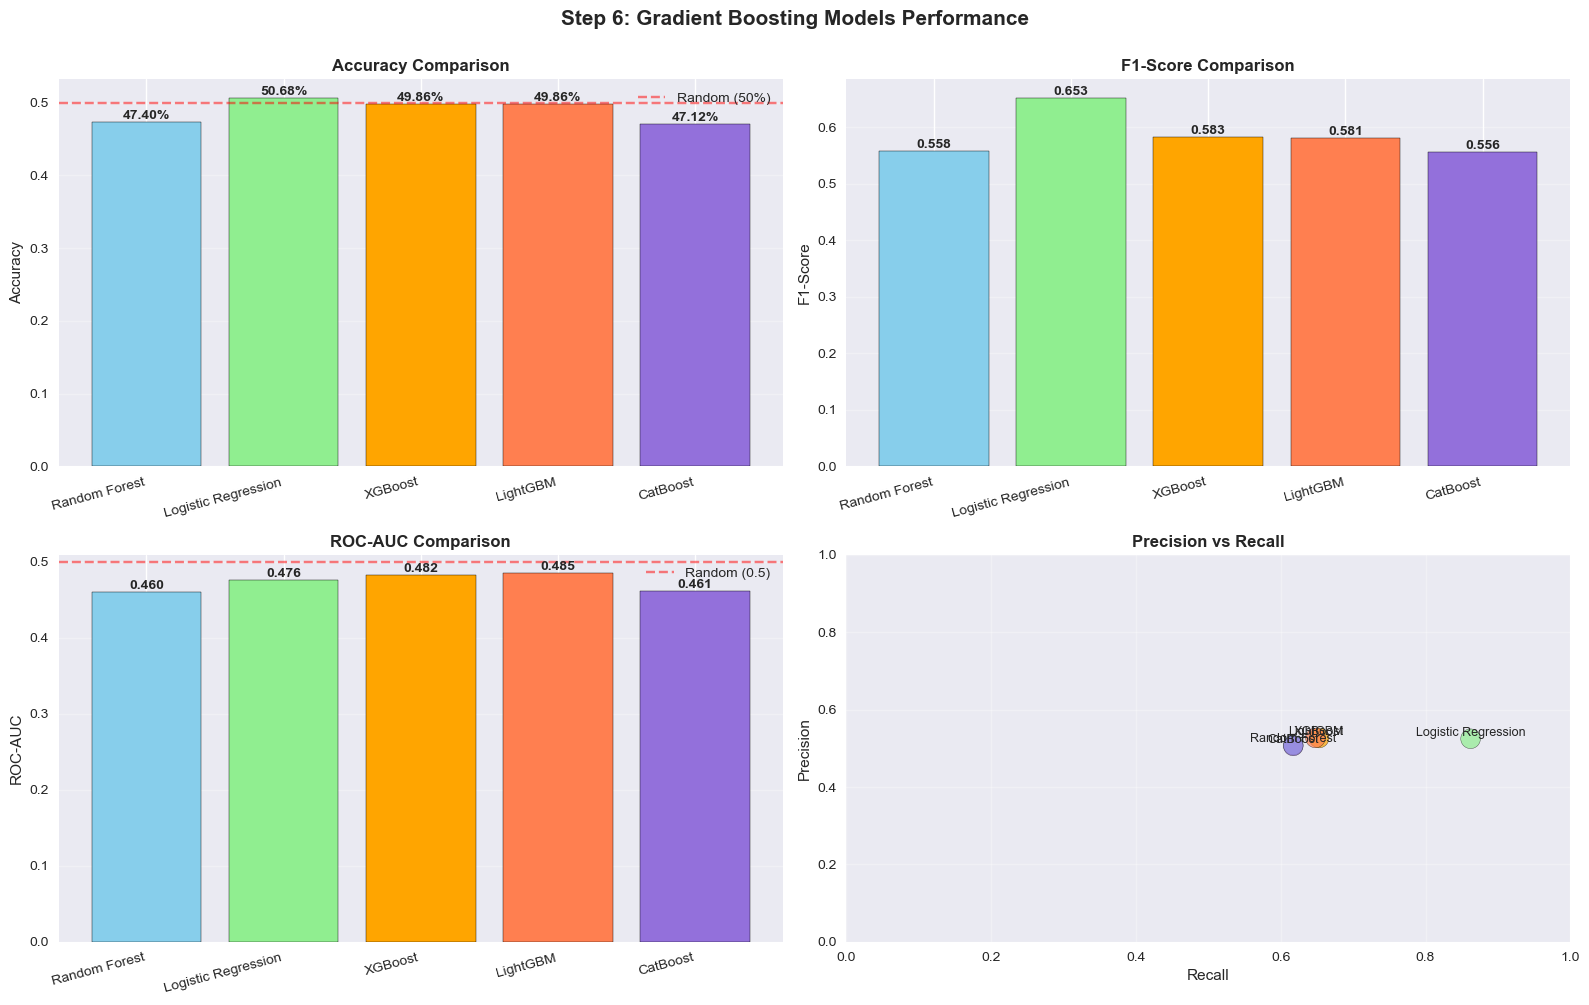

In [10]:
# Create comparison charts
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

models = results_df['Model'].values
colors = ['skyblue', 'lightgreen', 'orange', 'coral', 'mediumpurple']
x = np.arange(len(models))

# Accuracy
bars1 = axes[0, 0].bar(x, results_df['Accuracy'], color=colors, edgecolor='black')
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Accuracy Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=15, ha='right')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random (50%)')
axes[0, 0].legend()
for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.2%}', ha='center', va='bottom', fontweight='bold')

# F1-Score
bars2 = axes[0, 1].bar(x, results_df['F1-Score'], color=colors, edgecolor='black')
axes[0, 1].set_ylabel('F1-Score', fontsize=11)
axes[0, 1].set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=15, ha='right')
axes[0, 1].grid(True, alpha=0.3, axis='y')
for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# ROC-AUC
bars3 = axes[1, 0].bar(x, results_df['ROC-AUC'], color=colors, edgecolor='black')
axes[1, 0].set_ylabel('ROC-AUC', fontsize=11)
axes[1, 0].set_title('ROC-AUC Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models, rotation=15, ha='right')
axes[1, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].legend()
for bar in bars3:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

# Precision vs Recall
axes[1, 1].scatter(results_df['Recall'], results_df['Precision'], 
                   s=200, c=colors, edgecolors='black', alpha=0.7)
for i, model in enumerate(models):
    axes[1, 1].annotate(model, 
                        (results_df['Recall'].iloc[i], results_df['Precision'].iloc[i]),
                        fontsize=9, ha='center', va='bottom')
axes[1, 1].set_xlabel('Recall', fontsize=11)
axes[1, 1].set_ylabel('Precision', fontsize=11)
axes[1, 1].set_title('Precision vs Recall', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim([0, 1])
axes[1, 1].set_ylim([0, 1])

plt.suptitle('Step 6: Gradient Boosting Models Performance', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 7. ROC Curve Comparison

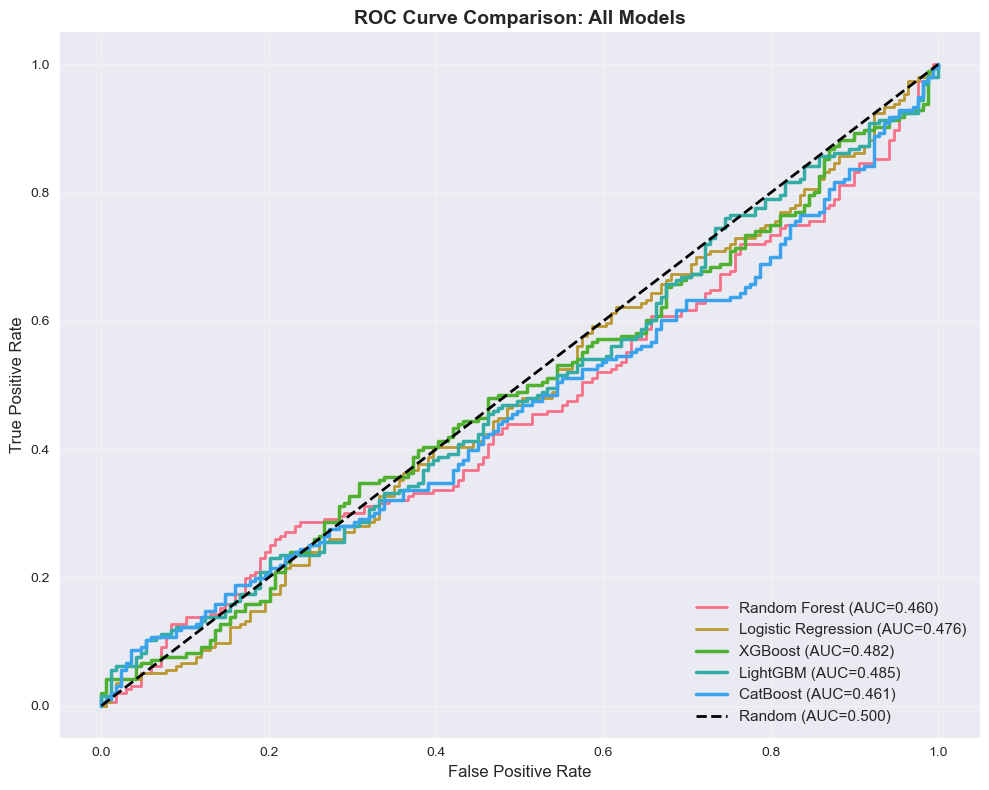

In [11]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', linewidth=2)

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})', linewidth=2)

# XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_proba)
auc_xgb = auc(fpr_xgb, tpr_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})', linewidth=2.5)

# LightGBM
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, lgbm_proba)
auc_lgbm = auc(fpr_lgbm, tpr_lgbm)
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC={auc_lgbm:.3f})', linewidth=2.5)

# CatBoost
fpr_cat, tpr_cat, _ = roc_curve(y_test, catboost_proba)
auc_cat = auc(fpr_cat, tpr_cat)
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC={auc_cat:.3f})', linewidth=2.5)

# Random classifier
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.500)', linewidth=2)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison: All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Confusion Matrix Comparison

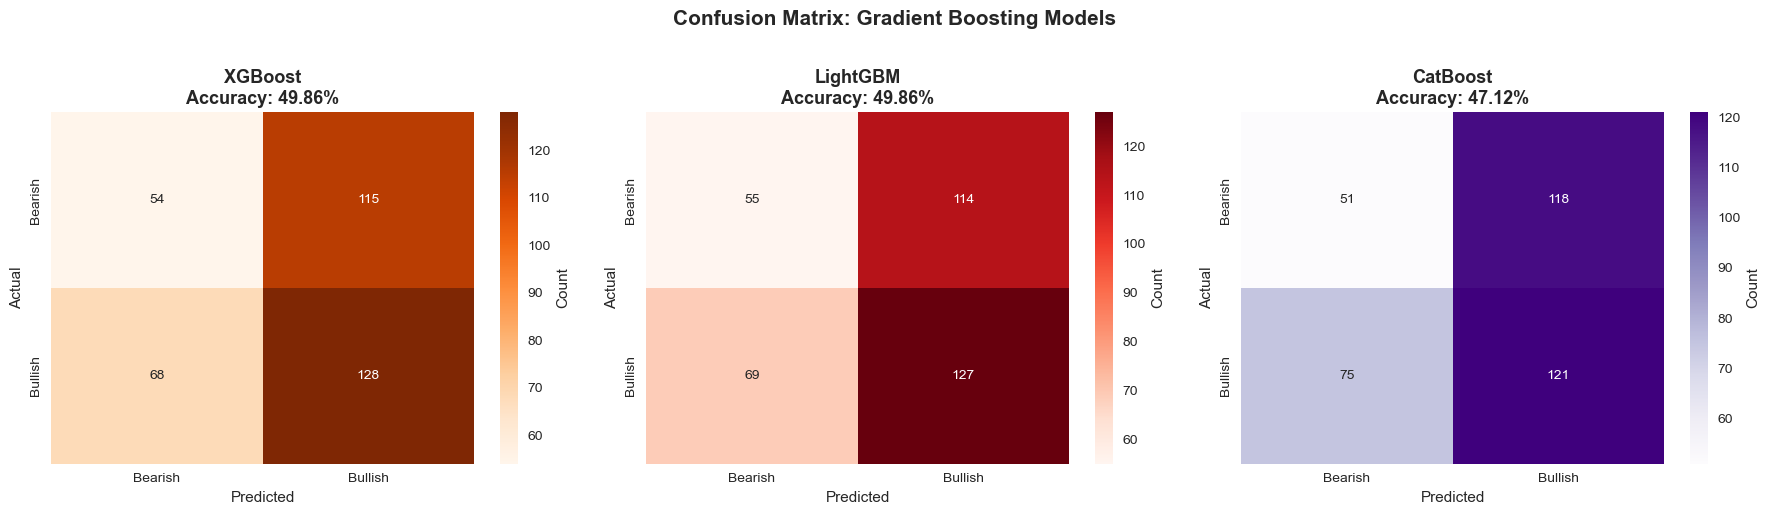

In [12]:
# Plot confusion matrices for gradient boosting models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# XGBoost
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[0], cbar_kws={'label': 'Count'})
axes[0].set_title(f'XGBoost\nAccuracy: {accuracy_score(y_test, xgb_pred):.2%}',
                  fontsize=13, fontweight='bold')
axes[0].set_ylabel('Actual', fontsize=11)
axes[0].set_xlabel('Predicted', fontsize=11)

# LightGBM
cm_lgbm = confusion_matrix(y_test, lgbm_pred)
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[1], cbar_kws={'label': 'Count'})
axes[1].set_title(f'LightGBM\nAccuracy: {accuracy_score(y_test, lgbm_pred):.2%}',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Actual', fontsize=11)
axes[1].set_xlabel('Predicted', fontsize=11)

# CatBoost
cm_cat = confusion_matrix(y_test, catboost_pred)
sns.heatmap(cm_cat, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Bearish', 'Bullish'],
            yticklabels=['Bearish', 'Bullish'],
            ax=axes[2], cbar_kws={'label': 'Count'})
axes[2].set_title(f'CatBoost\nAccuracy: {accuracy_score(y_test, catboost_pred):.2%}',
                  fontsize=13, fontweight='bold')
axes[2].set_ylabel('Actual', fontsize=11)
axes[2].set_xlabel('Predicted', fontsize=11)

plt.suptitle('Confusion Matrix: Gradient Boosting Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 9. Feature Importance Comparison

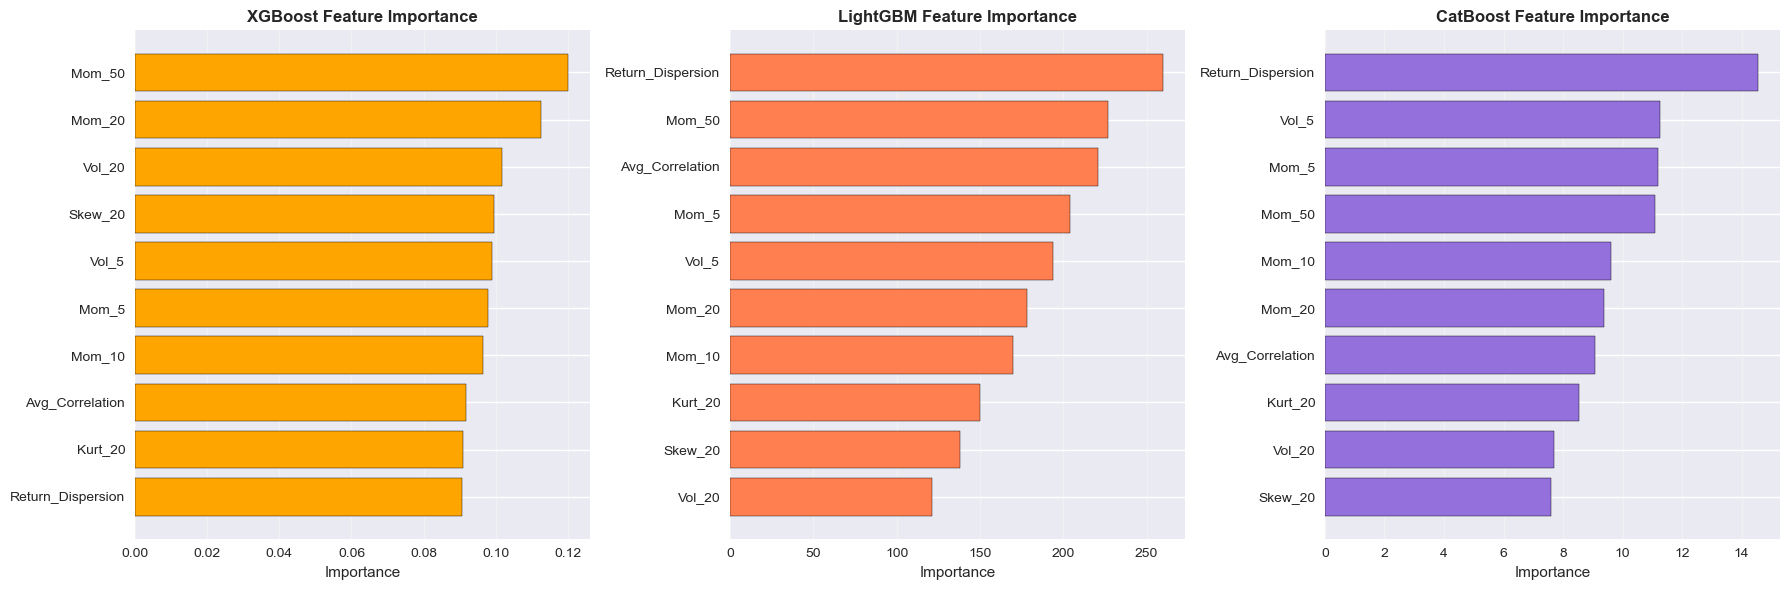


📊 Top 3 Features by Model:

XGBoost:
Feature  Importance
 Mom_50    0.120099
 Mom_20    0.112399
 Vol_20    0.101660

LightGBM:
          Feature  Importance
Return_Dispersion         260
           Mom_50         227
  Avg_Correlation         221

CatBoost:
          Feature  Importance
Return_Dispersion   14.562014
            Vol_5   11.266031
            Mom_5   11.179520


In [13]:
# Compare feature importance across gradient boosting models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# XGBoost
xgb_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[0].barh(xgb_importance['Feature'], xgb_importance['Importance'], 
             color='orange', edgecolor='black')
axes[0].set_xlabel('Importance', fontsize=11)
axes[0].set_title('XGBoost Feature Importance', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# LightGBM
lgbm_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': lgbm_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[1].barh(lgbm_importance['Feature'], lgbm_importance['Importance'], 
             color='coral', edgecolor='black')
axes[1].set_xlabel('Importance', fontsize=11)
axes[1].set_title('LightGBM Feature Importance', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# CatBoost
catboost_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': catboost_model.feature_importances_
}).sort_values('Importance', ascending=True)

axes[2].barh(catboost_importance['Feature'], catboost_importance['Importance'], 
             color='mediumpurple', edgecolor='black')
axes[2].set_xlabel('Importance', fontsize=11)
axes[2].set_title('CatBoost Feature Importance', fontsize=12, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n📊 Top 3 Features by Model:")
print("\nXGBoost:")
print(xgb_importance.sort_values('Importance', ascending=False).head(3).to_string(index=False))
print("\nLightGBM:")
print(lgbm_importance.sort_values('Importance', ascending=False).head(3).to_string(index=False))
print("\nCatBoost:")
print(catboost_importance.sort_values('Importance', ascending=False).head(3).to_string(index=False))

## 10. Summary & Next Steps

In [14]:
print("\n" + "="*80)
print("STEP 6: GRADIENT BOOSTING MODELS SUMMARY")
print("="*80)

print("\n📊 CONFIGURATION:")
print(f"  Features: 10 (same as Step 4)")
print(f"  Models: 5 (RF, LR, XGBoost, LightGBM, CatBoost)")
print(f"  Test Period: 2025")

print("\n🏆 PERFORMANCE RANKING (by Accuracy):")
ranked = results_df.sort_values('Accuracy', ascending=False)
for i, row in ranked.iterrows():
    print(f"  {i+1}. {row['Model']}: {row['Accuracy']:.2%} (F1={row['F1-Score']:.3f})")

print("\n📈 IMPROVEMENT ANALYSIS:")
baseline_lr = results_df[results_df['Model'] == 'Logistic Regression']['Accuracy'].values[0]
baseline_rf = results_df[results_df['Model'] == 'Random Forest']['Accuracy'].values[0]
best_gb = results_df[results_df['Type'] == 'Gradient Boosting']['Accuracy'].max()

print(f"  Baseline (LR): {baseline_lr:.2%}")
print(f"  Baseline (RF): {baseline_rf:.2%}")
print(f"  Best Gradient Boosting: {best_gb:.2%}")
print(f"  Improvement vs LR: {(best_gb - baseline_lr)*100:+.2f}%")
print(f"  Improvement vs RF: {(best_gb - baseline_rf)*100:+.2f}%")

print("\n💡 KEY INSIGHTS:")
if best_gb > max(baseline_lr, baseline_rf):
    print("  ✅ Gradient Boosting outperforms baseline models")
    print("  ✅ XGBoost/LightGBM/CatBoost capture non-linear patterns better")
else:
    print("  ⚠️ Gradient Boosting shows limited improvement")
    print("  💡 Problem may be in features or target definition")

if best_gb < 0.60:
    print("\n  ⚠️ WARNING: Accuracy still < 60%")
    print("  💡 RECOMMENDED NEXT STEPS:")
    print("     1. Step 7: Change target definition (magnitude-aware)")
    print("     2. Step 8: Add BTC-based technical indicators")
    print("     3. Step 9: Try regression instead of classification")
    print("     4. Step 10: Ensemble voting classifier")
else:
    print("\n  ✅ Accuracy > 60% - Acceptable for thesis")
    print("  💡 NEXT STEPS:")
    print("     - Integrate best model with full strategy")
    print("     - Run portfolio backtest")
    print("     - Compare vs baselines")

print("\n" + "="*80)


STEP 6: GRADIENT BOOSTING MODELS SUMMARY

📊 CONFIGURATION:
  Features: 10 (same as Step 4)
  Models: 5 (RF, LR, XGBoost, LightGBM, CatBoost)
  Test Period: 2025

🏆 PERFORMANCE RANKING (by Accuracy):
  2. Logistic Regression: 50.68% (F1=0.653)
  3. XGBoost: 49.86% (F1=0.583)
  4. LightGBM: 49.86% (F1=0.581)
  1. Random Forest: 47.40% (F1=0.558)
  5. CatBoost: 47.12% (F1=0.556)

📈 IMPROVEMENT ANALYSIS:
  Baseline (LR): 50.68%
  Baseline (RF): 47.40%
  Best Gradient Boosting: 49.86%
  Improvement vs LR: -0.82%
  Improvement vs RF: +2.47%

💡 KEY INSIGHTS:
  ⚠️ Gradient Boosting shows limited improvement
  💡 Problem may be in features or target definition

  ⚠️ WARNING: Accuracy still < 60%
  💡 RECOMMENDED NEXT STEPS:
     1. Step 7: Change target definition (magnitude-aware)
     2. Step 8: Add BTC-based technical indicators
     3. Step 9: Try regression instead of classification
     4. Step 10: Ensemble voting classifier

